In [ ]:
# 1. put output noisy image and then check whther it is learning and wht is the output whether it is a correct image or different image

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#Prepare Dataset

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
#Adding noise
# def add_noise(img, noise_factor=0.5):#noise factor is a scaling coefficient, increase/decrease amount of noise
#     noisy = img + noise_factor * torch.randn_like(img) #torch.randn_like(img) generates random values ~ N(0,1) (mean 0, std 1), it is a tensor of the same shape as img
#     noisy = torch.clamp(noisy, 0., 1.) #noisy images may have values below 0 and above 1, this function fixes this by clipping values to [0,1]
#     return noisy



# pattern noise
# def add_noise(img, noise_factor=0.5):
#     img = img.float()

#     B, C, H, W = img.shape

#     # Create vertical stripe pattern
#     pattern = torch.zeros((H, W), device=img.device)
#     pattern[:, ::4] = 1.0   # every 4th column is bright

#     pattern = pattern.unsqueeze(0).unsqueeze(0)  # shape (1,1,H,W)
#     pattern = pattern.repeat(B, C, 1, 1)

#     noisy = img + noise_factor * pattern
#     noisy = torch.clamp(noisy, 0., 1.)

#     return noisy






# pattern + random
def add_noise(img, noise_factor=0.3):
    img = img.float()

    # random noise
    random_noise = torch.randn_like(img)

    # stripe pattern
    B, C, H, W = img.shape
    pattern = torch.zeros((H, W), device=img.device)
    pattern[:, ::6] = 1.0
    pattern = pattern.unsqueeze(0).unsqueeze(0).repeat(B, C, 1, 1)

    noisy = img + noise_factor * random_noise + 0.2 * pattern
    noisy = torch.clamp(noisy, 0., 1.)

    return noisy

In [ ]:
# Autoencoder model
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),#first layer
            nn.ReLU(),
            nn.Linear(256, 64),#code/bottleneck layer
            nn.ReLU()
        )

#Input image is now represented as 64-dimensional vector

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),  #Maps the 64-dimensional bottleneck vector back to 256 features(first step of reconstruction)
            nn.ReLU(),
            nn.Linear(256, 28*28), #Maps 256 features back to the original input dimension (the output is a flat vector representing the reconstructed image)
            nn.Sigmoid() #maps values between 0 and 1, matching the input image pixel range
        )



    def forward(self, x):
        encoded = self.encoder(x)  #Compress
        decoded = self.decoder(encoded) #reconstruction
        decoded = decoded.view(-1, 1, 28, 28) #Reshape to image format (batch_size, channels, height, width)
        return decoded



In [ ]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



In [ ]:
# Training loop
epochs = 5

for epoch in range(epochs):
    for img, _ in train_loader:
        img = img.to(device)

        noisy_img = add_noise(img)

        output = model(noisy_img)

        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch [1/5], Loss: 0.0297
Epoch [2/5], Loss: 0.0190
Epoch [3/5], Loss: 0.0166
Epoch [4/5], Loss: 0.0149
Epoch [5/5], Loss: 0.0146


In [ ]:
# # Training loop
# epochs = 5

# for epoch in range(epochs):
#     for img, _ in train_loader:
#         img = img.to(device)

#         noisy_img = add_noise(img)

#         output = model(noisy_img)

#         img = add_noise(img)

#         loss = criterion(output, img)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



In [ ]:
#Testing
# dataiter = iter(test_loader) #creates a Python iterator over the batches.
# images, _ = next(dataiter) #next() gets the next batch from the iterator and - ignores labels.

# newNoisyoutput  = add_noise(images).to(device)

# noisy_imgs = add_noise(images).to(device)
# outputs = model(noisy_imgs).cpu().detach() #matplotlib cannot handle GPU tensors, This function Denoise & move results back to CPU for plotting




#Testing
dataiter = iter(test_loader) #creates a Python iterator over the batches.
images, _ = next(dataiter) #next() gets the next batch from the iterator and - ignores labels.

# newNoisyoutput  = add_noise(images).to(device)

noisy_imgs = add_noise(images).to(device)
outputs = model(noisy_imgs).cpu().detach() #matplotlib cannot handle GPU tensors, This function Denoise & move results back to CPU for plotting

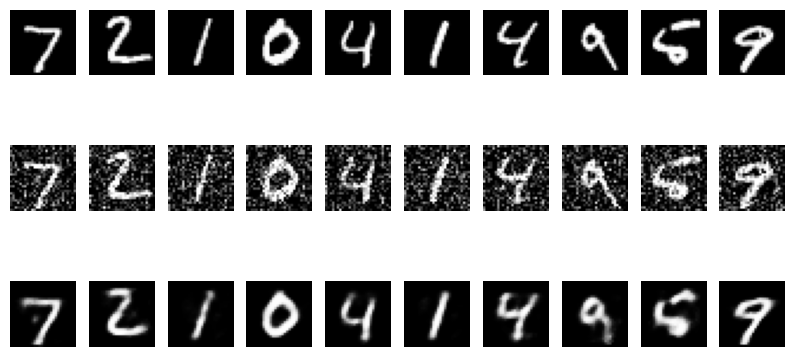

In [ ]:


# # display images
# fig, axes = plt.subplots(4, 10, figsize=(10,5))

# for i in range(10):
#     axes[0,i].imshow(images[i].squeeze(), cmap="gray") #squeeze() removes the channel dimension because imshow expects 2D
#     axes[0,i].axis("off")

#     axes[1,i].imshow(noisy_imgs.cpu()[i].squeeze(), cmap="gray")
#     axes[1,i].axis("off")

#     axes[2,i].imshow(outputs[i].squeeze(), cmap="gray")
#     axes[2,i].axis("off")

#     # new original noisy imagee
#     axes[3,i].imshow(newNoisyoutput.cpu()[i].squeeze(), cmap="gray")
#     axes[3,i].axis("off")

# axes[0,0].set_ylabel("Original")
# axes[1,0].set_ylabel("Noisy")
# axes[2,0].set_ylabel("Denoised")
# axes[3,0].set_ylabel("orignalnoise")

# plt.show()




# for pattern noise
fig, axes = plt.subplots(3, 10, figsize=(10,5))

for i in range(10):
    axes[0,i].imshow(images[i].squeeze(), cmap="gray") #squeeze() removes the channel dimension because imshow expects 2D
    axes[0,i].axis("off")

    axes[1,i].imshow(noisy_imgs.cpu()[i].squeeze(), cmap="gray")
    axes[1,i].axis("off")

    axes[2,i].imshow(outputs[i].squeeze(), cmap="gray")
    axes[2,i].axis("off")


axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Noisy")
axes[2,0].set_ylabel("Denoised")

plt.show()